In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append("..")

In [4]:
import datetime
import os
import pickle
import random
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping
from ignite.handlers.param_scheduler import create_lr_scheduler_with_warmup
from ignite.metrics import Accuracy, Loss
from ignite.utils import convert_tensor
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from clinic_datasets import CleanClinicDataset
from metrics import SklearnClassificationReport
from ignite.metrics.confusion_matrix import ConfusionMatrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utils import *
from model import BertGAT, BertGCN
import torch.utils.data as Data

from captum.attr import LayerIntegratedGradients, TokenReferenceBase, visualization
import shap

Using backend: pytorch


In [6]:
MODELPATH = "deepset/gbert-base"
LEARNINGRATE = 5e-5
NEPOCHS = 50
BATCHSIZE = 8
ACCUSTEPS = 8

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

tokenizer = AutoTokenizer.from_pretrained(MODELPATH)
SAVENAME = Path(MODELPATH).stem

dataset_file = Path("../data") / "medindcls_bert.json"
if not dataset_file.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(dataset_file, "wb") as f:
        print(f"Saving dataset under {dataset_file}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {dataset_file}")
    with open(dataset_file, "rb") as f:
        dataset = pickle.load(f)

SAVEPATH = Path(f"../models/finetuned/{SAVENAME}_{dataset}_best.pt")

device = "cpu"

model = AutoModelForSequenceClassification.from_pretrained(MODELPATH, num_labels=len(dataset.LE.classes_))
model = model.to(device)

idx = np.arange(len(dataset))
random.shuffle(idx)

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

test_dataset = Subset(dataset, test_idx)

Loading dataset from: ../data/medindcls_bert.json


Some weights of the model checkpoint at deepset/gbert-base were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint a

In [7]:
print(f"Loading best model from {SAVEPATH} saved on {datetime.datetime.fromtimestamp(SAVEPATH.stat().st_ctime)}")
ckpt = torch.load(SAVEPATH, map_location="cpu")
model.bert.load_state_dict(ckpt["bert_model"])
model.classifier.load_state_dict(ckpt["classifier"])

Loading best model from ../models/finetuned/gbert-base_med_indication_all_RF_diag_best.pt saved on 2022-10-27 15:55:48


<All keys matched successfully>

In [14]:
def forward(inputs):
    preds = model(inputs)
    #print(preds.logits.shape)
    return preds.logits

token_reference = TokenReferenceBase(reference_token_idx=tokenizer.pad_token_id)
lig = LayerIntegratedGradients(forward, model.bert.embeddings)

In [15]:
vis_data_records_ig = []

def add_attributions_to_visualizer(attributions, text, pred, pred_ind, label, delta, vis_data_records):
    attributions = attributions.sum(dim=2).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = attributions.cpu().detach().numpy()
    # storing couple samples in an array for visualization purposes
    vis_data_records.append(visualization.VisualizationDataRecord(
                        attributions,
                        pred,
                        dataset.LE.classes_[pred_ind], # predicted
                        dataset.LE.classes_[label], # true
                        dataset.LE.classes_[label], # attributed
                        attributions.sum(),
                        text,
                        delta))

def interpret_sentence(model, indexed, label):
    model.zero_grad()

    input_indices = torch.tensor(indexed, device=device)
    input_indices = input_indices.unsqueeze(0)
    pred = model(input_indices).logits
    pred_ind = torch.argmax(pred).item()
    pred = torch.argmax(torch.softmax(pred, dim=-1)).item()

    reference_indices = token_reference.generate_reference(len(indexed), device=device).unsqueeze(0)

    # compute attributions and approximation delta using layer integrated gradients
    label = torch.tensor(label)
    attributions_ig, delta = lig.attribute(input_indices, reference_indices, n_steps=50, target=label, return_convergence_delta=True)
    text = tokenizer.convert_ids_to_tokens(indexed)
    add_attributions_to_visualizer(attributions_ig, text, pred, pred_ind, label, delta, vis_data_records_ig)

In [16]:
for sample in np.array(dataset.examples)[test_idx][24:25]:
    print(dataset.LE.classes_[sample["labels"]])
    interpret_sentence(model, sample["input_ids"], sample["labels"])

Blutdrucksenker_Blutdruck
torch.Size([1, 12])
torch.Size([1, 12])
torch.Size([50, 12])
torch.Size([1, 12])
torch.Size([1, 12])


In [17]:
_ = visualization.visualize_text(vis_data_records_ig)

Token indices sequence length is longer than the specified maximum sequence length for this model (1488 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

Partition explainer: 2it [01:34, 94.11s/it]               


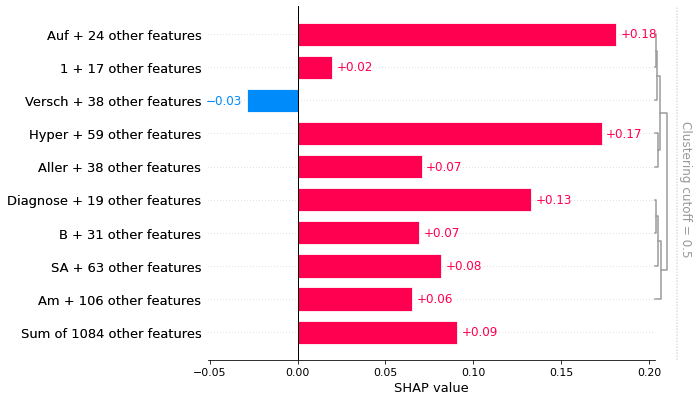

In [18]:
def shap_func(x):
    tv = torch.tensor([tokenizer.encode(v, padding='max_length', max_length=500, truncation=True) for v in x])
    outputs = model(tv)
    return torch.softmax(outputs.logits, dim=-1).detach().numpy()

explainer = shap.Explainer(shap_func, tokenizer)

for sample in np.array(dataset.texts)[test_idx][24:25]:
    label = np.array(dataset.examples)[test_idx][24]["labels"]
    shap_values = explainer([sample])
    shap.plots.text(shap_values[0, :, label])
    shap.plots.bar(shap_values[0, :, label], order=shap.Explanation.argsort.flip)

In [21]:
shap_values[0, :, 0]

.values =
array([1.13950846e-03, 1.13950846e-03, 1.13950846e-03, ...,
       6.31405135e-11, 6.31405135e-11, 6.31405135e-11])

.base_values =
0.1385221779346466

.data =
array(['', 'Arznei ', 'Ram', ..., 'Ober', 'arzt', ''], dtype='<U15')